<a href="https://colab.research.google.com/github/FabrizioBettetti/Deep_learning/blob/main/Predicting_heart_disease_Binary_classification_on_tabular_data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Predicting heart desease - binary classification on tabular data

## Preliminaries

In [1]:
import tensorflow as tf
from tensorflow import keras
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# Set a random seed for ALL randomness sources (starting values for weights, minibatches in SGD, train-validation-test splits, dropout, ...)
# for reproducibility
keras.utils.set_random_seed(42)

## Read in the data

In [3]:
df = pd.read_csv("http://storage.googleapis.com/download.tensorflow.org/data/heart.csv")

In [4]:
df.shape

(303, 14)

In [5]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,1,145,233,1,2,150,0,2.3,3,0,fixed,0
1,67,1,4,160,286,0,2,108,1,1.5,2,3,normal,1
2,67,1,4,120,229,0,2,129,1,2.6,2,2,reversible,0
3,37,1,3,130,250,0,0,187,0,3.5,3,0,normal,0
4,41,0,2,130,204,0,2,172,0,1.4,1,0,normal,0


In [6]:
# Are target values balanced?
df.target.value_counts(normalize=True, dropna=False)

,proportion
target,
0,0.726073
1,0.273927


A model that predicts always 0s will have 72.6% of accuracy on training data (baseline model)

## Preprocessing

In [7]:
categorical_variables = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'ca', 'thal']
numerical_variables = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak', 'slope']

In [8]:
# One-hot encoding of categorical attributes
df = pd.get_dummies(df, columns=categorical_variables, dtype=int)

In [9]:
df.head()

,age,trestbps,chol,thalach,oldpeak,slope,target,sex_0,sex_1,cp_0,...,exang_1,ca_0,ca_1,ca_2,ca_3,thal_1,thal_2,thal_fixed,thal_normal,thal_reversible
0,63,145,233,150,2.3,3,0,0,1,0,...,0,1,0,0,0,0,0,1,0,0
1,67,160,286,108,1.5,2,1,0,1,0,...,1,0,0,0,1,0,0,0,1,0
2,67,120,229,129,2.6,2,0,0,1,0,...,1,0,0,1,0,0,0,0,0,1
3,37,130,250,187,3.5,3,0,0,1,0,...,0,1,0,0,0,0,0,0,1,0
4,41,130,204,172,1.4,1,0,1,0,0,...,0,1,0,0,0,0,0,0,1,0


Train-test split before standardization of numerical attributes because means and standard deviations must refer on training set only

In [10]:
test_df = df.sample(frac=0.2, random_state=42)
train_df = df.drop(test_df.index)

In [11]:
train_df.shape

(242, 30)

In [12]:
test_df.shape

(61, 30)

In [13]:
means = train_df[numerical_variables].mean()
sd = train_df[numerical_variables].std()

In [14]:
means

,0
age,54.268595
trestbps,131.995868
chol,246.512397
thalach,149.805785
oldpeak,1.032645
slope,1.590909


In [15]:
train_df[numerical_variables] = (train_df[numerical_variables] - means) / sd

In [16]:
test_df[numerical_variables] = (test_df[numerical_variables] - means) / sd

In [17]:
train_df.head()

,age,trestbps,chol,thalach,oldpeak,slope,target,sex_0,sex_1,cp_0,...,exang_1,ca_0,ca_1,ca_2,ca_3,thal_1,thal_2,thal_fixed,thal_normal,thal_reversible
0,0.963746,0.721939,-0.278690,0.008396,1.083461,2.226814,0,0,1,0,...,0,1,0,0,0,0,0,1,0,0
1,1.405254,1.554681,0.814423,-1.807247,0.399542,0.646494,1,0,1,0,...,1,0,0,0,1,0,0,0,1,0
2,1.405254,-0.665964,-0.361189,-0.899426,1.339930,0.646494,0,0,1,0,...,1,0,0,1,0,0,0,0,0,1
3,-1.906055,-0.110803,0.071931,1.607891,2.109339,2.226814,0,0,1,0,...,0,1,0,0,0,0,0,0,1,0
4,-1.464547,-0.110803,-0.876809,0.959447,0.314052,-0.933825,0,1,0,0,...,0,1,0,0,0,0,0,0,1,0


In [18]:
train = train_df.to_numpy()
test = test_df.to_numpy()

In [19]:
train_X = np.delete(train, 6, axis=1)
test_X = np.delete(test, 6, axis=1)

In [20]:
train_X.shape, test_X.shape

((242, 29), (61, 29))

In [21]:
train_y = train[:, 6]
test_y = test[:, 6]

In [22]:
train_y.shape, test_y.shape

((242,), (61,))

## Build a model

### Define model in Keras

In [23]:
num_columns = train_X.shape[1]

# Input layer
input = keras.Input(shape=(num_columns,), name="Input")

# Feed it to hidden layer. Give a name to this layer
h = keras.layers.Dense(16, activation='relu', name='Hidden')(input)

# Feed it to the output layer
output = keras.layers.Dense(1, activation='sigmoid', name='Output')(h)

# Input-output model
model = keras.Model(input, output)

In [24]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Input (InputLayer)              │ (None, 29)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Hidden (Dense)                  │ (None, 16)             │           480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output (Dense)                  │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 497 (1.94 KB)

 Trainable params: 497 (1.94 KB)

 Non-trainable params: 0 (0.00 B)

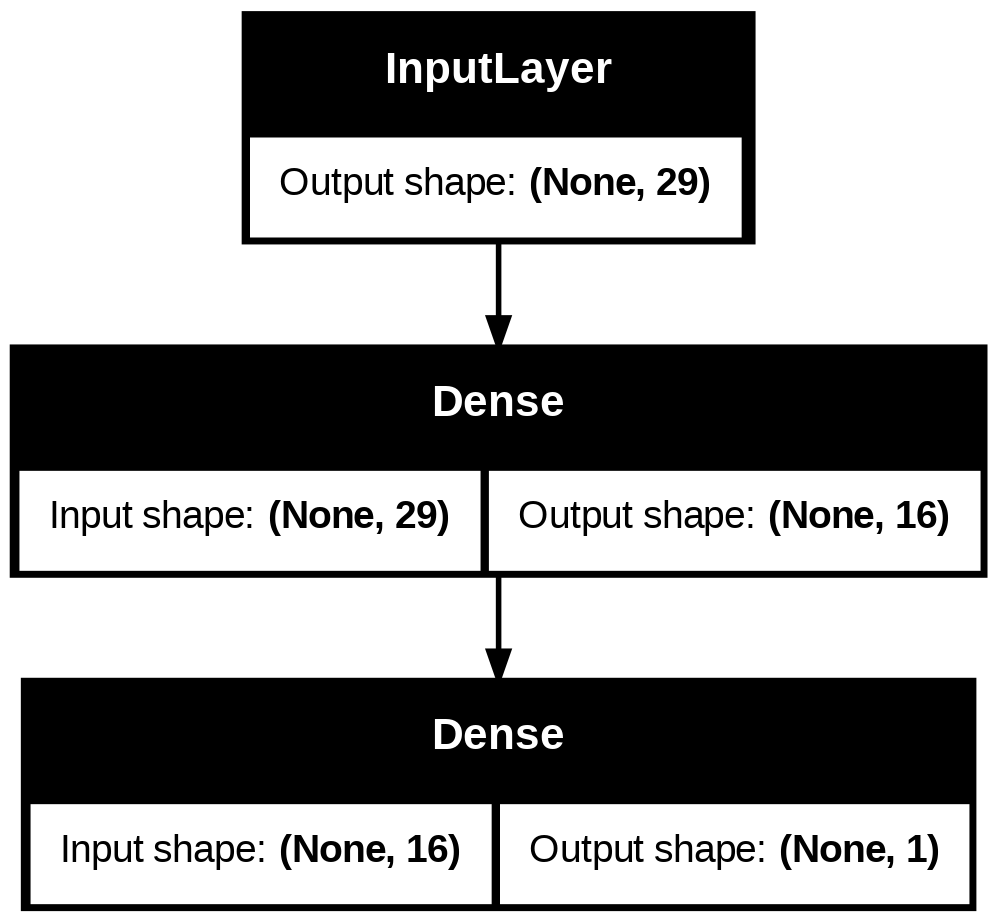

In [25]:
keras.utils.plot_model(model, show_shapes=True)

### Set optimization parameters

In [26]:
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

## Train the model

In [27]:
history = model.fit(train_X,
                    train_y,
                    epochs=300,
                    batch_size=32,   # Minibatches for Adam SGD
                    verbose=1,
                    validation_split=0.2)   # Training, after each epoch, on trainin set minus 20% of training set (validation set)

Epoch 1/300
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 196ms/step - accuracy: 0.5511 - loss: 0.7246 - val_accuracy: 0.5918 - val_loss: 0.6891
Epoch 2/300
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.6019 - loss: 0.6898 - val_accuracy: 0.6122 - val_loss: 0.6697
Epoch 3/300
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6082 - loss: 0.6660 - val_accuracy: 0.6122 - val_loss: 0.6530
Epoch 4/300
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6477 - loss: 0.6450 - val_accuracy: 0.6122 - val_loss: 0.6372
Epoch 5/300
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6715 - loss: 0.6256 - val_accuracy: 0.6531 - val_loss: 0.6225
Epoch 6/300
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7010 - loss: 0.6072 - val_accuracy: 0.6939 - val_loss: 0.6088
Epoch 7/300
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7350 - loss: 0.5902 - val_accuracy: 0.6939 - val_loss: 0.5959
Epoch 8/300
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7517 - loss: 0.5743 - val_accuracy: 0.7143 - val_loss

In [28]:
history_dict = history.history
history_dict.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

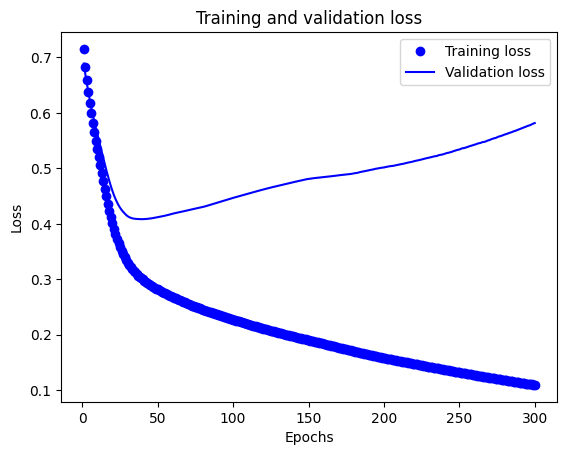

In [29]:
loss_values = history_dict['loss']
val_loss_values = history_dict['val_loss']
epochs = range(1, len(loss_values) + 1)
plt.plot(epochs, loss_values, 'bo', label='Training loss')
plt.plot(epochs, val_loss_values, 'b', label='Validation loss')
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

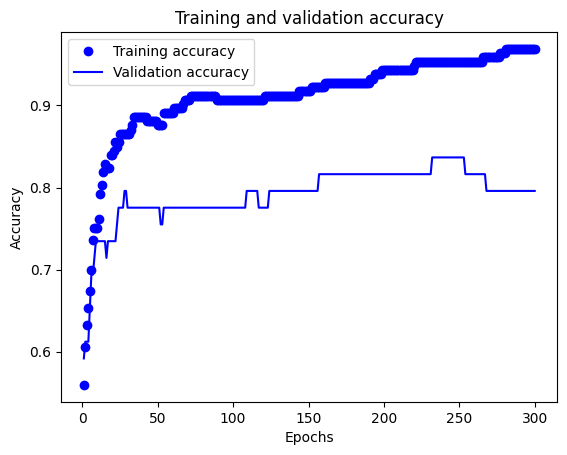

In [30]:
plt.clf()
acc = history_dict['accuracy']
val_acc = history_dict['val_accuracy']
epochs = range(1, len(loss_values) + 1)
plt.plot(epochs, acc, 'bo', label='Training accuracy')
plt.plot(epochs, val_acc, 'b', label='Validation accuracy')
plt.title('Training and validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

Validation loss increases after slightly 50 epochs while validation accuracy tends to constantly increase.

Because accuracy is more realistic and practical than loss, we consider accuracy for validation and we keep 300 epochs as best

## Evaluate the model

In [31]:
model.evaluate(test_X, test_y)

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 550ms/step - accuracy: 0.8490 - loss: 0.4713


[0.4810093939304352, 0.8360655903816223]

83.6% > 72.6% of the previous baseline model!